### 1. 가상 데이터셋을 생성한 뒤, 학습·검증·테스트 데이터셋으로 분할해 보세요. 

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
# 데이터셋 생성
# 가상의 이커머스 쇼핑몰 매출 데이터

np.random.seed(42)
n = 500

categories = ['Electronics', 'Clothing', 'Food', 'Books', 'Sports']
regions = ['Seoul', 'Busan', 'Incheon', 'Daegu', 'Gwangju']
customers = [f'C{str(i).zfill(3)}' for i in range(1, 51)] # 고객 50명

data = {
    'order_id': range(1, n + 1),
    'date': pd.date_range('2024-01-01', periods=n, freq='14h'),
    'customer_id': np.random.choice(customers, n),
    'category': np.random.choice(categories, n),
    'region': np.random.choice(regions, n),
    'sales': np.random.randint(10000, 500000, n),
    'quantity': np.random.randint(1, 10, n),
}

df = pd.DataFrame(data)
df

,order_id,date,customer_id,category,region,sales,quantity
0,1,2024-01-01 00:00:00,C039,Sports,Incheon,337304,3
1,2,2024-01-01 14:00:00,C029,Books,Seoul,289746,6
2,3,2024-01-02 04:00:00,C015,Electronics,Daegu,375464,9
3,4,2024-01-02 18:00:00,C043,Sports,Gwangju,98801,1
4,5,2024-01-03 08:00:00,C008,Clothing,Incheon,298075,5
...,...,...,...,...,...,...,...
495,496,2024-10-15 18:00:00,C005,Food,Busan,239027,6
496,497,2024-10-16 08:00:00,C012,Electronics,Incheon,415804,1
497,498,2024-10-16 22:00:00,C016,Clothing,Seoul,393894,8
498,499,2024-10-17 12:00:00,C026,Books,Incheon,242750,8


In [3]:
# 데이터셋 분할
# # 직접 분할

# 데이터 비율 설정
train_size = int(0.6 * len(df))
validation_size = int(0.2 * len(df))
test_size = len(df) - train_size - validation_size

# 분할
train_data = df[:train_size]
validation_data = df[train_size:train_size + validation_size]
test_data = df[train_size + validation_size:]

# 결과 확인
print("직접 분할 - 학습 데이터셋 크기:", len(train_data))
print("직접 분할 - train data:", train_data.head())
print()
print("직접 분할 - 검증 데이터셋 크기:", len(validation_data))
print("직접 분할 - validation data:", validation_data.head())
print()
print("직접 분할 - 테스트 데이터셋 크기:", len(test_data))
print("직접 분할 - test data:", test_data.head())
print()

직접 분할 - 학습 데이터셋 크기: 300
직접 분할 - train data:    order_id                date customer_id     category   region   sales  \
0         1 2024-01-01 00:00:00        C039       Sports  Incheon  337304   
1         2 2024-01-01 14:00:00        C029        Books    Seoul  289746   
2         3 2024-01-02 04:00:00        C015  Electronics    Daegu  375464   
3         4 2024-01-02 18:00:00        C043       Sports  Gwangju   98801   
4         5 2024-01-03 08:00:00        C008     Clothing  Incheon  298075   

   quantity  
0         3  
1         6  
2         9  
3         1  
4         5  

직접 분할 - 검증 데이터셋 크기: 100
직접 분할 - validation data:      order_id                date customer_id  category   region   sales  \
300       301 2024-06-24 00:00:00        C036  Clothing  Incheon  106347   
301       302 2024-06-24 14:00:00        C038      Food    Daegu  320931   
302       303 2024-06-25 04:00:00        C040      Food    Seoul  307632   
303       304 2024-06-25 18:00:00        C020     Books

In [4]:
# 데이터셋 분할
# # 랜덤 분할 기법
train_data_rd, test_data_rd = train_test_split(df, test_size=0.2, random_state=42)
train_data_rd, validation_data_rd = train_test_split(train_data_rd, test_size=0.25, random_state=42)

print("랜덤 분할 - 학습 데이터셋 크기:", len(train_data_rd))
print("랜덤 분할 - train data:", train_data_rd.head())
print()
print("랜덤 분할 - 검증 데이터셋 크기:", len(validation_data_rd))
print("랜덤 분할 - validation data:", validation_data_rd.head())
print()
print("랜덤 분할 - 테스트 데이터셋 크기:", len(test_data_rd))
print("랜덤 분할 - test data:", test_data_rd.head())

랜덤 분할 - 학습 데이터셋 크기: 300
랜덤 분할 - train data:      order_id                date customer_id     category   region   sales  \
421       422 2024-09-02 14:00:00        C015  Electronics    Seoul  451124   
250       251 2024-05-25 20:00:00        C036  Electronics  Incheon   89083   
247       248 2024-05-24 02:00:00        C029         Food  Gwangju  270550   
26         27 2024-01-16 04:00:00        C022        Books    Seoul  398411   
198       199 2024-04-25 12:00:00        C044  Electronics    Seoul  372130   

     quantity  
421         5  
250         6  
247         5  
26          1  
198         1  

랜덤 분할 - 검증 데이터셋 크기: 100
랜덤 분할 - validation data:      order_id                date customer_id     category   region   sales  \
120       121 2024-03-11 00:00:00        C012     Clothing    Seoul  416723   
128       129 2024-03-15 16:00:00        C044  Electronics  Incheon  483611   
271       272 2024-06-07 02:00:00        C030     Clothing    Busan  171087   
349       350 2024-

### 2. 가상 데이터셋을 생성하고, K-최근접이웃(K-NN) 알고리즘으로 학습·예측을 수행해 보세요. 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris, load_diabetes, make_classification, make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

#### 2.1 KNN 분류

In [6]:
# 데이터셋 생성
X, y = make_classification(
    n_samples=200, n_features=2, n_informative=2, n_redundant=0,
    n_classes=3, n_clusters_per_class=1, random_state=42
)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("클래스:", set(y))

Feature shape: (200, 2)
Target shape: (200,)
클래스: {np.int64(0), np.int64(1), np.int64(2)}


In [7]:
# 데이터셋 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (160, 2)
Test shape: (40, 2)


In [8]:
# 데이터 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# k 탐색
scores = []
ks = list(range(3, 10, 2))

for k in ks:
    knc = KNeighborsClassifier(n_neighbors=k)
    knc.fit(X_train, y_train)
    scores.append(knc.score(X_test, y_test))

best_k = ks[scores.index(max(scores))]
print(f"scores: {scores}")
print(f"최적 k: {best_k}, 정확도: {max(scores):.4f}")

scores: [0.825, 0.825, 0.825, 0.875]
최적 k: 9, 정확도: 0.8750


In [10]:
# 최적 k로 모델 학습
knn_classifier = KNeighborsClassifier(n_neighbors=best_k)
knn_classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=9)

In [11]:
# 예측 및 평가
y_pred = knn_classifier.predict(X_test)
accuracy = knn_classifier.score(X_test, y_test)

print(f"테스트 데이터 정확도: {accuracy:.4f}")
print(f"예측값: {y_pred[0]}, 정답: {y_test[0]}")

테스트 데이터 정확도: 0.8750
예측값: 1, 정답: 1


#### 2.2 KNN 회귀

In [12]:
# 데이터셋 생성
X, y = make_regression(n_samples=200, n_features=1, noise=0.1, random_state=42)

In [13]:
# 데이터셋 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

# 분할한 데이터셋 확인
print("Train feature shape:", X_train.shape)
print("Test feature shape:", X_test.shape)

Train feature shape: (160, 1)
Test feature shape: (40, 1)


In [14]:
# 데이터 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
# KNN Regressor 학습
scores = []

for k in range(3, 10, 2):
    knr = KNeighborsRegressor(n_neighbors=k)
    knr.fit(X_train, y_train)

    scores.append(knr.score(X_test,y_test))

# k값 3, 5, 7, 9 별로 성능 확인
scores

[0.9870340161078807,
 0.9817384115764595,
 0.9774614521909272,
 0.9722015175037984]

In [16]:
# 가장 높은 k=3으로 모델 학습
knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=3)

In [17]:
y_pred = knr.predict(X_test)

In [18]:
# 모델 평가
accuracy = knr.score(X_test, y_test)
print(f"테스트 데이터 정확도: {accuracy:.4f}")

# 예측
print(f"예측값: {y_pred[0]}")
print(f"정답 값: {y_test[0]}")

테스트 데이터 정확도: 0.9870
예측값: 67.4831944019436
정답 값: 68.67211978162588


### 3. 동일한 이진 분류 가상 데이터셋을 생성하고, Perceptron, SVM, Random Forest, Naive Bayes 네 가지 알고리즘으로 학습해 보세요. 

In [2]:
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

#### 데이터셋 준비

In [20]:
# 데이터셋 생성
X, y = make_classification(
    n_samples=500, n_features=3, n_informative=2, n_redundant=0,
    n_classes=2, random_state=42
)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("클래스:", set(y))

Feature shape: (500, 3)
Target shape: (500,)
클래스: {np.int64(0), np.int64(1)}


In [21]:
# 데이터셋 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 데이터 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# PyTorch Tensor 변환 (X: float32, y: long)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (400, 3)
Test shape: (100, 3)


#### 3.1 Perceptron

In [22]:
# 가중치 및 편향 초기화
weights = np.random.rand(3)
bias = np.random.rand(1)

In [23]:
print(weights)
print(bias)

[0.97599085 0.6673504  0.0104277 ]
[0.25541348]


In [24]:
# 하이퍼파라미터 설정
learning_rate = 0.1
epochs = 10

In [25]:
# 활성화 함수 정의
def step_function(x):
    return 1 if x >= 0 else 0

In [26]:
# 퍼셉트론 학습
for epoch in range(epochs):
    for i in range(len(X_train)):
        total_input = np.dot(X_train[i], weights) + bias
        prediction = step_function(total_input)
        error = y_train[i] - prediction
        weights += learning_rate * error * X_train[i]
        bias += learning_rate * error

In [27]:
print("학습된 가중치:", weights)
print("학습된 편향:", bias)

학습된 가중치: [-0.08621627  0.14734729  0.26274271]
학습된 편향: [-0.04458652]


In [28]:
# 예측 함수 정의 및 테스트 데이터 예측
def predict(input_data):
    total_input = np.dot(input_data, weights) + bias
    return step_function(total_input)

y_pred_perceptron = [predict(x) for x in X_test]

In [29]:
# 성능 평가
perceptron_acc = accuracy_score(y_test, y_pred_perceptron)
print(f"Accuracy: {perceptron_acc:.4f}")

Accuracy: 0.8200


#### 3.2 SVM

In [30]:
# SVM 모델
svm_model = SVC(kernel='linear')

# 모델 학습
svm_model.fit(X_train_tensor.numpy(), y_train_tensor.numpy())

SVC(kernel='linear')

In [ ]:
# 모델 평가
accuracy = svm_model.score(X_test_tensor.numpy(), y_test_tensor.numpy())
print(f"테스트 데이터 정확도: {accuracy:.4f}")

# 샘플 데이터 예측 (첫 번째 테스트 샘플 예측)
sample = X_test_tensor[0].reshape(1, -1).numpy()  # 입력 데이터 형태 맞추기
prediction = svm_model.predict(sample)

print(f"예측된 클래스: {prediction}")

테스트 데이터 정확도: 0.8700
예측된 클래스: [0.]


#### 3.3 Random Forest

In [36]:
# Random Forest 모델 생성 및 학습
rf_model1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model1.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [37]:
# 튜닝된 Random Forest 모델 생성 및 학습
rf_model2 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model2.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [38]:
# 두 모델 평가
accuracy1 = rf_model1.score(X_test, y_test)
accuracy2 = rf_model2.score(X_test, y_test)

# 평가 결과 출력
print(f"\n기본 모델 테스트 정확도: {accuracy1:.4f}")
print(f"튜닝된 모델 (num_trees=100, max_depth=10) 테스트 정확도: {accuracy2:.4f}")


기본 모델 테스트 정확도: 0.9100
튜닝된 모델 (num_trees=100, max_depth=10) 테스트 정확도: 0.9200


In [39]:
# 예측 수행 (상위 5개 샘플)
probs1 = rf_model1.predict_proba(X_test)[:5]
probs2 = rf_model2.predict_proba(X_test)[:5]

# 예측 결과 출력
print("\n기본 모델 예측 (상위 5개 확률 분포):")
print(probs1.flatten())

print("\n튜닝된 모델 예측 (상위 5개 확률 분포):")
print(probs2.flatten())


기본 모델 예측 (상위 5개 확률 분포):
[0.97 0.03 0.03 0.97 0.37 0.63 0.83 0.17 1.   0.  ]

튜닝된 모델 예측 (상위 5개 확률 분포):
[0.97068485 0.02931515 0.03055556 0.96944444 0.37801136 0.62198864
 0.83974775 0.16025225 0.99506102 0.00493898]


In [ ]:
# 성능 평가
y_pred1 = rf_model1.predict(X_test)
y_pred2 = rf_model2.predict(X_test)

print(f"기본 모델 정확도:   {accuracy_score(y_test, y_pred1):.4f}")
print(f"튜닝 모델 정확도:   {accuracy_score(y_test, y_pred2):.4f}")

기본 모델 정확도:   0.9100
튜닝 모델 정확도:   0.9200


#### 3.4 Naive Bayes

In [41]:
# 가우시안 나이브 베이즈 모델 생성
nb_model = GaussianNB()

# 모델 학습
nb_model.fit(X_train_tensor.numpy(), y_train_tensor.numpy())

GaussianNB()

In [42]:
# 모델 평가
accuracy = nb_model.score(X_test_tensor.numpy(), y_test_tensor.numpy())
print(f"테스트 데이터 정확도: {accuracy:.4f}")

# 샘플 데이터 예측 (첫 번째 테스트 샘플 예측)
sample = X_test_tensor[0].reshape(1, -1).numpy()  # 입력 데이터 형태 맞추기
prediction = nb_model.predict(sample)

print(f"예측된 클래스: {prediction}")

테스트 데이터 정확도: 0.9000
예측된 클래스: [0.]


In [43]:
# 4개 알고리즘 성능 비교
perceptron_acc = accuracy_score(y_test, y_pred_perceptron)
svm_acc        = svm_model.score(X_test_tensor.numpy(), y_test_tensor.numpy())
rf_acc         = rf_model1.score(X_test, y_test)
nb_acc         = nb_model.score(X_test_tensor.numpy(), y_test_tensor.numpy())

results = {
    "Perceptron (직접 구현)": perceptron_acc,
    "SVM (linear kernel)":   svm_acc,
    "Random Forest":         rf_acc,
    "Naive Bayes":           nb_acc,
}

print("=" * 40)
print(f"{'알고리즘':<25} {'정확도':>8}")
print("-" * 40)
for name, acc in results.items():
    print(f"{name:<25} {acc:>8.4f}")

알고리즘                           정확도
----------------------------------------
Perceptron (직접 구현)          0.8200
SVM (linear kernel)         0.8700
Random Forest               0.9100
Naive Bayes                 0.9000


### 4. 가상 데이터셋을 준비하고, 증강(Data Augmentation) 기법을 적용했을 때와 적용하지 않았을 때 모델 성능을 비교하세요. 

In [9]:
import torch
from torchvision import datasets
from torchvision.transforms import transforms
from torch.utils.data import DataLoader

In [10]:
# 데이터셋 불러오기
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train = datasets.CIFAR10(root='./data',
                        train=True, 
                        transform=transform_base, 
                        download=True)

test = datasets.CIFAR10(root='./data', 
                        train=False, 
                        transform=transform_base, 
                        download=True)

In [11]:
# 데이터 로더
train_loader = DataLoader(train, batch_size=64, shuffle=True)
test_loader = DataLoader(test, batch_size=64, shuffle=False)

In [12]:
# 데이터 증강
# pytorch로 데이터 증강 적용
transform_aug = transforms.Compose([
    transforms.RandomRotation(15), # 임의로 사진 15도 회전
    transforms.RandomHorizontalFlip(), # 임의로 사진 뒤집기
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_aug = datasets.CIFAR10(root='./data',
                        train=True, 
                        transform=transform_aug, 
                        download=False)

train_aug_loader = DataLoader(train_aug, batch_size=64, shuffle=True)

### 5. 활성화 함수를 직접 정의하고, 활성화 함수를 적용한 출력을 계산하고, 결과를 그래프로 시각화하세요. 

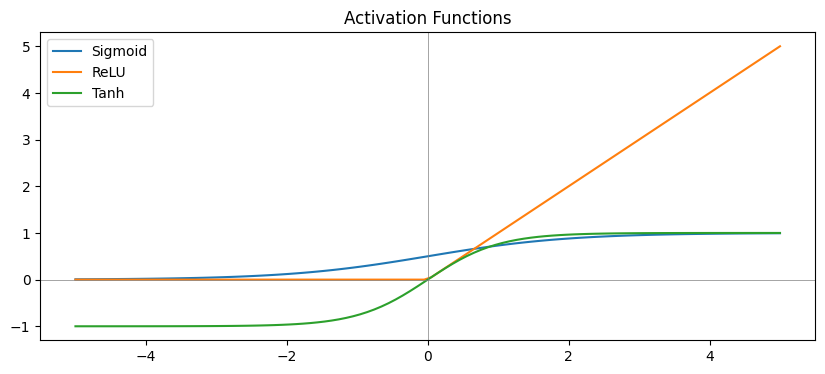

In [ ]:
# 입력값
x = np.linspace(-5, 5, 100)

# 기본 활성화함수 정의 - sigmoid, relu, tanh
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

# 시각화
plt.figure(figsize=(10, 4))
for name, fn in [("Sigmoid", sigmoid), ("ReLU", relu), ("Tanh", tanh)]:
    plt.plot(x, fn(x), label=name)

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.legend()
plt.title("Activation Functions")
plt.show()

In [ ]:
# 출력값 확인
value = np.random.uniform(-3, 3)
print(f"입력값: {value:.4f}")

print(f"sigmoid({value:.4f}) = {sigmoid(value):.4f}")
print(f"tanh({value:.4f})    = {tanh(value):.4f}")
print(f"relu({value:.4f})    = {relu(value):.4f}")

입력값: -1.6929
sigmoid(-1.6929) = 0.1554
tanh(-1.6929)    = -0.9345
relu(-1.6929)    = 0.0000


### 6. 비선형 데이터셋을 생성하고, MLP(다층 퍼셉트론) 모델을 설계하고 학습시켜 분류를 수행하세요. 

### 7. CNN(Convolutional Neural Network)을 직접 구성하여 이미지 분류를 수행하세요.